# Homework 2 - MTH 602

William Girard

Due Date: October 5th, 2026

## Floating Point Numbers

### 1. (15 points) Consider an 𝑁-term Taylor series expansion of the exponential function

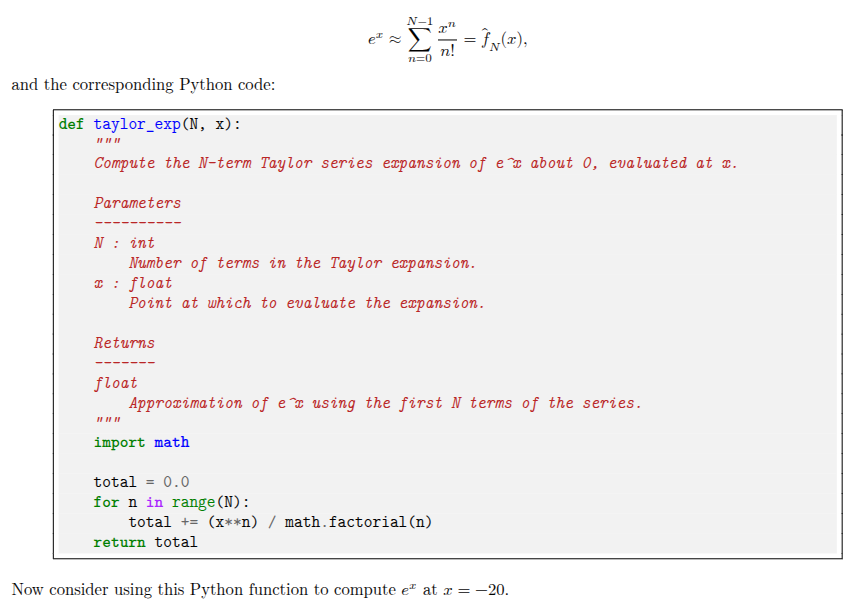

(a) (5 points) Plot the relative error 

\begin{align*}
  E_N = \frac{|\hat{f}_N(-20) - e^{-20}|}{|e^{-20}|}
\end{align*}

as a function of 𝑁 for 𝑁 = 1, 2, ....  What is the smallest relative error you can achieve?  Make the plot using a 
semilog-𝑦 scale.


In [7]:
import math

In [8]:
def taylor_exp(N, x):

    """
    Compute the N-term Taylor series expansion of e^x about 0, evaluated at x.
    
    Parameters
    ----------
    N : int
    Number of terms in the Taylor expansion.
    x : float
    Point at which to evaluate the expansion.

    Returns
    -------
    float
    Approximation of e^x using the first N terms of the series.
    """
 
    total = 0.0
    for n in range(N):
        total += (x**n) / math.factorial(n)

    return total

In [9]:
# experiment with a few large values of N

print(taylor_exp(200, -20))
print(taylor_exp(500, -20))
print(taylor_exp(1000, -20))

5.47810291652921e-10
5.47810291652921e-10
5.47810291652921e-10


In [10]:
N = 200 # higher N values don't approximate any better (plateau)
error_list = []

for n in range(1, N+1):

    approx = taylor_exp(n, -20)
    true_e = math.exp(-20)
    error = (abs(approx - true_e))/(abs(true_e))
    error_list.append(error)

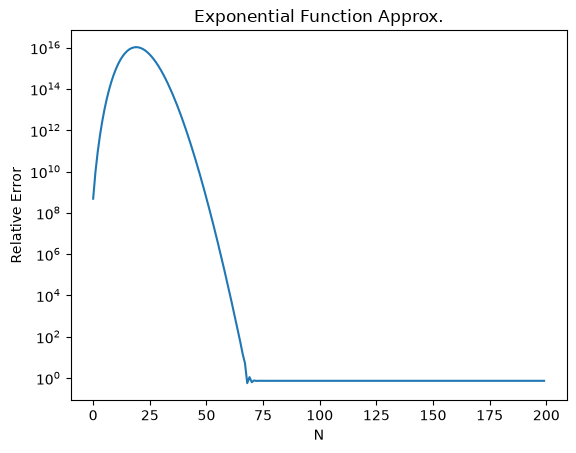


Minimum error obtained was: 0.5665545568629835


In [11]:
import matplotlib.pyplot as plt

plt.plot(list(range(N)), error_list)
plt.semilogy()
plt.title('Exponential Function Approx.')
plt.xlabel('N')
plt.ylabel('Relative Error')
plt.show()

print(f'\nMinimum error obtained was: {min(error_list)}')

The relative error starts off very high before dropping down and becoming constant. However, the minimum error of 0.5665545568629835 is much much larger than the expected error of $10^{-16}$ , so, clearly something is wrong.

(b) (5 points) You should find the relative error is much larger than the expected value of $\approx 10^{-16}$. Briefly explain the 
numerical reason for this behavior (hint: think about cancellation when 𝑥 is negative and large in magnitude).

In [41]:
# print each term in the taylor series
# will help me answer part B by investigating what the terms are actually evaluating to 

def mod_taylor_exp(N, x):

    """
    Compute the N-term Taylor series expansion of e^x about 0, evaluated at x.
    
    Parameters
    ----------
    N : int
    Number of terms in the Taylor expansion.
    x : float
    Point at which to evaluate the expansion.

    Returns
    -------
    float
    Approximation of e^x using the first N terms of the series.
    """
 
    total = 0.0
    for n in range(N):
        total += (x**n) / math.factorial(n)
        print(f'Current term: {(x**n) / math.factorial(n)} - Running Total: {total}')

    return total

total = mod_taylor_exp(100, -20)
print(f'\nTotal: {total}')

Current term: 1.0 - Running Total: 1.0
Current term: -20.0 - Running Total: -19.0
Current term: 200.0 - Running Total: 181.0
Current term: -1333.3333333333333 - Running Total: -1152.3333333333333
Current term: 6666.666666666667 - Running Total: 5514.333333333334
Current term: -26666.666666666668 - Running Total: -21152.333333333336
Current term: 88888.88888888889 - Running Total: 67736.55555555556
Current term: -253968.25396825396 - Running Total: -186231.6984126984
Current term: 634920.6349206349 - Running Total: 448688.9365079365
Current term: -1410934.7442680777 - Running Total: -962245.8077601411
Current term: 2821869.4885361553 - Running Total: 1859623.6807760142
Current term: -5130671.797338464 - Running Total: -3271048.1165624503
Current term: 8551119.662230773 - Running Total: 5280071.545668323
Current term: -13155568.711124267 - Running Total: -7875497.165455945
Current term: 18793669.58732038 - Running Total: 10918172.421864435
Current term: -25058226.116427176 - Running Tota

The above printed lines reveal the reason why the actual error is so much higher than the expected error. The term is constantly being added to negative numbers. Therefore, two problems with computer arithmetic are coming together to cause a huge problem: rounding errors and catastrophic cancellation.

1) Rounding errors are occuring due to the limited precision of computers. Decimal numbers may be unbound, but a computer can only store the integer result up to a certain number of bits (such as floating-point 32 or 64). Normally, this isn't too much of a problem. But repeated subtraction of rounded numbers can result in catastrophic cancellation.
2) According to David Goldberg, "Catastrophic cancellation occurs when the operands are subject to rounding errors." When the cancellation occurs, many of the actually accurate bits/digits may disappear, leaving behind bits/digits contaiminated by rounding error. 

[David Goldberg's paper](https://docs.oracle.com/cd/E19957-01/806-3568/ncg_goldberg.html)

Therefore, the most obvious solution would be to avoid catastrophic cancellation, which means avoiding subtraction of rounded floating point numbers. 

To do this, I looked up expoential rules in hopes of finding an equivalent to the negative power. Thankfully, a negative exponent can be represented as:

$$
a^{-x} = \frac{1}{a^x}
$$

Therefore, all you need to do to avoid the catastrophic cancellation is to compute $x^{20}$ and then do 1 divided by $x^{20}$ to obtain $x^{-20}$

In [9]:
N = 200 # higher N values don't approximate better
error_list = []

for n in range(1, N+1):

    approx_pos = taylor_exp(n, 20) # compute regular e^20
    approx = 1/approx_pos # get e^-20 by doing 1/e^20
    true_e = math.exp(-20)
    error = (abs(approx - true_e))/(abs(true_e))
    error_list.append(error)

print(min(error_list))

2.0065962176423985e-16


As can be observed, the error is now $2 \times 10^{-16}$, which is a much closer expected error when compared to the original error of a very large 0.5

### 2. Matrix-vector multiplication

In [2]:
import numpy as np

print(np.finfo(np.float32).eps) # machine eplison in float 32

1.1920929e-07


In [4]:
A = [
    [1000, 0],
    [0, 0.01]
]

A_inv = np.linalg.inv(A) # compute inverse as done by hand in math notebook

np.linalg.cond(A_inv)

np.float64(100000.0)

## Is there a signal in my time-series data? Application of probability theory

### Part 2:

Set 𝑁 = 1000. Plot the empirical distribution of 𝜌(𝐴) for 𝐴 ∈ {0, 3, 10}. That is, for each 𝐴,
generate many data realizations by calling generate_data and compute 𝜌(𝐴) for each one. Overlay each
histogram with the corresponding theoretical Gaussian distribution using the mean and variance you derived
above (label the curves clearly). Use these plots to confirm your formulas.

In [15]:
import numpy as np
import scipy

def generate_data(A, N, seed=None):

    """ Generate a noisy time series dataset {t_i, y_i}_{i=1}^N.

    Parameters
    ----------
    A : float
        Amplitude of the signal (A >= 0)
    N : int
        Number of data points. Time points uniformly sampled from [0, 2pi]
    seed : int or None, optional
        Random seed for reproducibility """

    rng = np.random.default_rng(seed)
    t = np.linspace(0.0, 2*np.pi, N)
    dt = (2*np.pi) / (N - 1)

    s_hat = np.sqrt(dt / np.pi) * np.sin(t) # ||s_hat||_2 == 1 exactly on this grid
    s = A * s_hat
    n = rng.normal(loc=0.0, scale=1.0, size=N)
    y = s + n

    return t, y, s, n, s_hat, dt

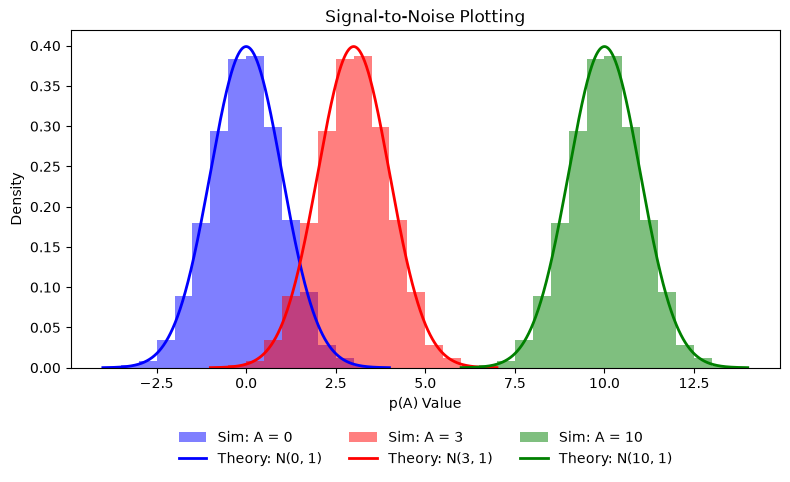

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import norm

A_list = [0, 3, 10]
N = 1000
N_sims = 10000 # number of realizations

bins = np.arange(-4, 14.5, 0.5)  # same bin width for every histogram
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["blue", "red", "green"]


for A, color in zip(A_list, colors):

    samples = []
    for i in range(0, N_sims):

        t, y, s, n, s_hat, dt = generate_data(A, 1000, seed=i) # seed=i
        p_A = np.dot(y, s_hat)
        samples.append(p_A)
    
    # computed gaussian has mean = A, std. dev = 1
    x = np.linspace(A - 4, A + 4, 1000)  # 4 std. dev, 1000 samples for smooth curve

    ax.hist(samples, bins=bins, density=True, color=color, alpha=0.5,
            label=f"Sim: A = {A}")

    pdf_values = norm.pdf(x, loc=A, scale=1) # where loc is mean and scale is std. dev
    ax.plot(x, pdf_values, color=color, lw=2,
            label=f"Theory: N({A}, 1)")

ax.set_title("Signal-to-Noise Plotting")
ax.set_xlabel("p(A) Value")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
ax.set_ylabel("Density")
plt.tight_layout()
plt.show()

As can be observed from the above graph, my Gaussian of theory matches the simulated plots. This is a good sign that my math in the first part of this problem was correct!

### Part 3:

(10 points) Now consider two possibilities: no signal (𝐴 = 0) or a signal (𝐴 > 0). From the previous question,
observe that for large enough 𝐴, the 𝜌(𝐴 = 0) distribution is well separated from the 𝜌(𝐴 ≠ 0) distribution.
For example, if 𝐴 = 10, setting 𝜌0 = 5 should separate the no-signal and signal classes nearly perfectly. But
for smaller values of 𝐴 the distributions of 𝜌(𝐴 = 0) and 𝜌(𝐴) overlap, leading to possible misclassification.
There are four outcomes:
1. True positive: You declare “signal present,” and indeed a signal really was present in the data.
2. True negative: You declare “no signal,” and indeed there was no signal in the data (only noise).
3. False positive: You declare “signal present,” but in reality there was no signal (just noise mimicking a
signal-like feature).
4. False negative: You declare “no signal,” but there actually was a real signal present.

For the 𝐴 = 3 case, empirically choose a value of 𝜌0 that roughly balances the number of false positives and
false negatives for 1000 mock datasets. Present your results by constructing a confusion matrix.

In [66]:
import seaborn 

A_list = [0, 3] 
samples_dict = {}

N_sims = 1000 # 1k per each

for A in A_list:

    samples = []
    for i in range(0, N_sims):

        t, y, s, n, s_hat, dt = generate_data(A, 1000, seed=i) # seed=i
        p_A = np.dot(y, s_hat)
        samples.append(p_A)
    
    samples_dict[A] = samples


# sweep over a range from 0 threshold (everything is a signal) to a 1 threshold (everything is noise)
# where the 0 class is noise and the 1 class is signal

thresholds = np.linspace(0, 3, 101) # don't need to check past 3 because everything past 3 is a signal anyway and FP/FN will be super unbalanced

print(thresholds)

[0.   0.03 0.06 0.09 0.12 0.15 0.18 0.21 0.24 0.27 0.3  0.33 0.36 0.39
 0.42 0.45 0.48 0.51 0.54 0.57 0.6  0.63 0.66 0.69 0.72 0.75 0.78 0.81
 0.84 0.87 0.9  0.93 0.96 0.99 1.02 1.05 1.08 1.11 1.14 1.17 1.2  1.23
 1.26 1.29 1.32 1.35 1.38 1.41 1.44 1.47 1.5  1.53 1.56 1.59 1.62 1.65
 1.68 1.71 1.74 1.77 1.8  1.83 1.86 1.89 1.92 1.95 1.98 2.01 2.04 2.07
 2.1  2.13 2.16 2.19 2.22 2.25 2.28 2.31 2.34 2.37 2.4  2.43 2.46 2.49
 2.52 2.55 2.58 2.61 2.64 2.67 2.7  2.73 2.76 2.79 2.82 2.85 2.88 2.91
 2.94 2.97 3.  ]


In [67]:
FP = np.array([(samples_dict[0] >= th).sum() for th in thresholds])  # everything in A_0 is noise (noise called signal)
FN = np.array([(samples_dict[3] < th).sum() for th in thresholds])  # everything in A_3 is signal (signal called noise)

balance = np.array([abs(fp-fn) for fp, fn in zip(FP, FN)])
print(f'Smallest difference between FP and FN is: {min(balance)} at index: {np.argmin(balance)}')

Smallest difference between FP and FN is: 3 at index: 50


In [68]:
# now just get the corresponding threshold value

best_thresh = thresholds[50]
print(f'Threshold that balances FP and FN is {best_thresh}')

Threshold that balances FP and FN is 1.5


In [69]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

# make predictions
y_pred = []
all_points = samples_dict[0] + samples_dict[3]

y_pred = [0 if p <= best_thresh else 1 for p in all_points] # 0 = noise, 1 = signal
y_true = [0] * len(samples_dict[0]) + [1] * len(samples_dict[3]) # all points in A0 = noise, all points in A3 = signal

cm = confusion_matrix(y_true, y_pred)
cm

array([[929,  71],
       [ 68, 932]])

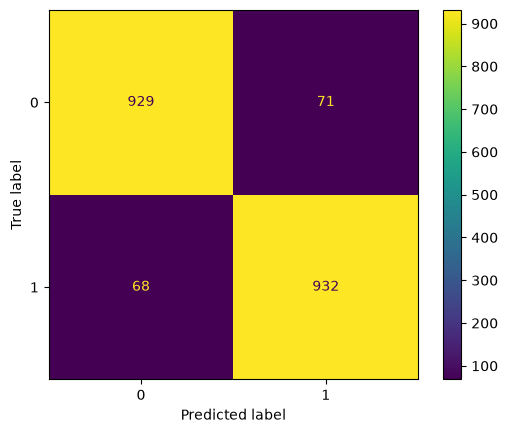

In [ ]:
# display confusion matrix

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### 